# Annotation Agent — Auto-labeling & Quality Report

| | |
|---|---|
| **Dataset** | `data/raw/unified_dataset.csv` (1 417 rows) |
| **Modality** | Text |
| **Model** | `distilbert-base-uncased-finetuned-sst-2-english` |
| **Task** | Binary sentiment classification (positive / negative) |

**Structure:**
1. Auto-labeling with DistilBERT
2. Annotation specification (`annotation_spec.md`)
3. Quality metrics (Cohen's κ vs. original labels)
4. LabelStudio export
5. **BONUS** — Human-in-the-loop (flag low-confidence)

In [1]:
import sys, pathlib, warnings
ROOT = pathlib.Path("..").resolve()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, JSON
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from agents.annotation_agent import AnnotationAgent

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

RAW = ROOT / "data" / "raw" / "unified_dataset.csv"
assert RAW.exists(), f"Run python run_agent.py first! ({RAW})"

df_raw = pd.read_csv(RAW)
# pandas-2 safe sampling per source
parts = [grp.sample(min(100, len(grp)), random_state=42)
         for _, grp in df_raw.groupby("source")]
sample = pd.concat(parts, ignore_index=True)
print(f"Working sample: {len(sample)} rows")
print(sample["source"].value_counts().to_string())
sample.head(3)


Working sample: 297 rows
source
books_toscrape      100
imdb_huggingface    100
openlibrary_api      97


,text,label,source,collected_at
0,Chasing Heaven: What Dying Taught Me About Living,negative,books_toscrape,2026-03-26T22:36:41.927378
1,My Kind of Crazy,negative,books_toscrape,2026-03-26T22:36:41.927378
2,The Bear and the Piano,negative,books_toscrape,2026-03-26T22:36:41.927378


---
## 1. Auto-labeling with DistilBERT 🤖

In [2]:
agent = AnnotationAgent(
    modality='text',
    labels=['positive', 'negative'],
    text_model='distilbert-base-uncased-finetuned-sst-2-english',
    zero_shot=False,
    batch_size=64,
    confidence_threshold=0.70,
    output_dir=ROOT / 'data' / 'annotations',
)
print('Agent created:', agent)

Agent created: <agents.annotation_agent.AnnotationAgent object at 0x11f8df770>


In [3]:
%%time
df_labeled = agent.auto_label(sample)
print(f'\nLabeled: {len(df_labeled)} rows')
print('\nPredicted label distribution:')
print(df_labeled['predicted_label'].value_counts().to_string())
print(f'\nMean confidence: {df_labeled["confidence"].mean():.3f}')
df_labeled[['text', 'label', 'predicted_label', 'confidence']].head(6)

2026-03-26 23:36:28,818 [INFO] agents.annotation_agent: auto_label: modality=text, rows=297


2026-03-26 23:36:30,089 [INFO] agents.annotation_agent: Loading text-classification pipeline: distilbert-base-uncased-finetuned-sst-2-english ...


2026-03-26 23:36:30,473 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english/resolve/main/config.json "HTTP/1.1 200 OK"


2026-03-26 23:36:30,475 [WARNING] huggingface_hub.utils._http: Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

...

2026-03-26 23:36:32,013 [INFO] httpx: HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased-finetuned-sst-2-english/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"


2026-03-26 23:36:32,196 [INFO] httpx: HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased-finetuned-sst-2-english/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"


2026-03-26 23:36:35,173 [INFO] agents.annotation_agent: auto_label done: {'positive': np.int64(186), 'negative': np.int64(111)}



Labeled: 297 rows

Predicted label distribution:
predicted_label
positive    186
negative    111

Mean confidence: 0.955
CPU times: user 2.75 s, sys: 603 ms, total: 3.35 s
Wall time: 6.36 s


,text,label,predicted_label,confidence
0,Chasing Heaven: What Dying Taught Me About Living,negative,positive,0.9918
1,My Kind of Crazy,negative,negative,0.9375
2,The Bear and the Piano,negative,positive,0.9903
3,"Pop Gun War, Volume 1: Gift",negative,positive,0.9989
4,Shakespeare's Sonnets,positive,positive,0.9447
5,The Third Wave: An Entrepreneurâs Vision of ...,positive,positive,0.9976


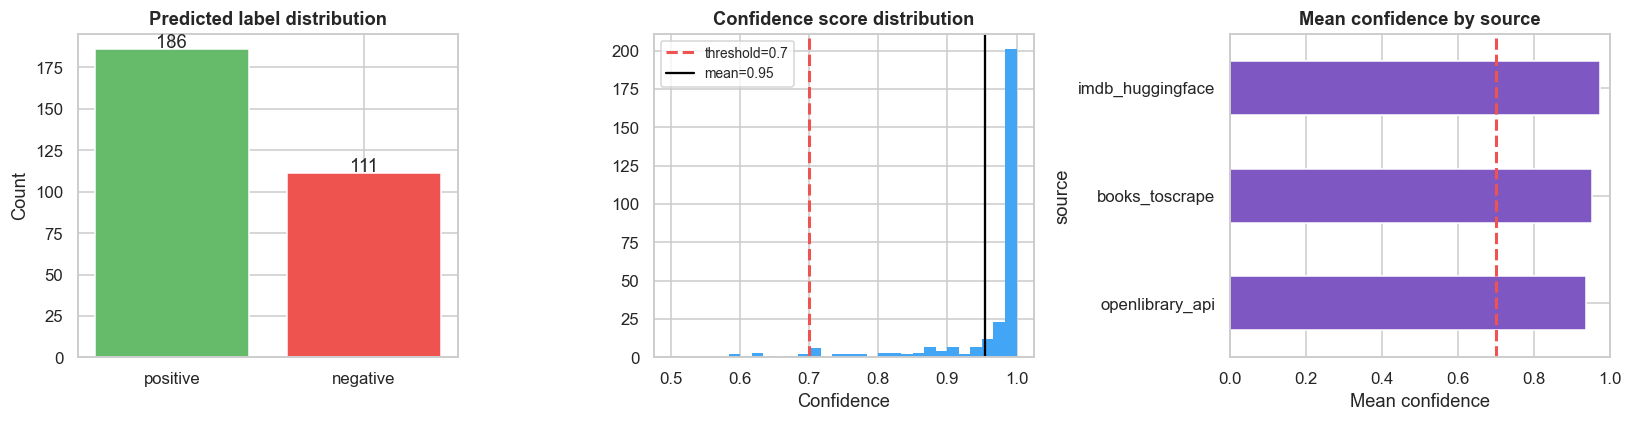

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
lp = {'positive': '#66BB6A', 'negative': '#EF5350'}

# Predicted label distribution
cnt = df_labeled['predicted_label'].value_counts()
axes[0].bar(cnt.index, cnt.values,
            color=[lp.get(l, '#90A4AE') for l in cnt.index], edgecolor='white')
axes[0].set_title('Predicted label distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(cnt.values):
    axes[0].text(i, v + 1, str(v), ha='center')

# Confidence histogram
axes[1].hist(df_labeled['confidence'], bins=30, color='#42A5F5', edgecolor='none')
axes[1].axvline(agent.confidence_threshold, color='#EF5350', lw=2, ls='--',
                label=f'threshold={agent.confidence_threshold}')
axes[1].axvline(df_labeled['confidence'].mean(), color='black', lw=1.5, ls='-',
                label=f'mean={df_labeled["confidence"].mean():.2f}')
axes[1].set_title('Confidence score distribution', fontweight='bold')
axes[1].set_xlabel('Confidence')
axes[1].legend(fontsize=9)

# Confidence by source
src_conf = df_labeled.groupby('source')['confidence'].mean().sort_values()
src_conf.plot.barh(ax=axes[2], color='#7E57C2', edgecolor='white')
axes[2].axvline(agent.confidence_threshold, color='#EF5350', lw=2, ls='--')
axes[2].set_title('Mean confidence by source', fontweight='bold')
axes[2].set_xlabel('Mean confidence')
axes[2].set_xlim(0, 1)

plt.tight_layout()
plt.savefig(ROOT / 'data/annotations/aplot_label_confidence.png', bbox_inches='tight')
plt.show()

---
## 2. Annotation Specification 📋

In [5]:
spec_path = agent.generate_spec(
    df=sample,
    task='sentiment_classification',
    text_col='text',
    label_col='label',
    n_examples=3,
)
print(f'Spec saved to: {spec_path}')
spec_text = open(spec_path, encoding='utf-8').read()
display(Markdown(spec_text))

2026-03-26 23:36:35,405 [INFO] agents.annotation_agent: Annotation spec saved → /Users/trof1mov/Documents/itmo data for ml/data/annotations/annotation_spec.md


Spec saved to: /Users/trof1mov/Documents/itmo data for ml/data/annotations/annotation_spec.md


# Annotation Specification: Sentiment Classification
**Generated:** 2026-03-26  |  **Agent:** AnnotationAgent v1.0

---

## 1. Task Description

**Goal:** Classify each text sample into one of `2` predefined classes.

**ML use case:** Binary sentiment classification of multi-source text data (movie reviews, book titles). The resulting labels will be used to train and evaluate a text classifier (e.g. DistilBERT fine-tuning).

**Input:** A single text string (review body or book title).
**Output:** One label from the set below.

---

## 2. Label Definitions

### `positive`

**Definition:** The text expresses a favourable, enthusiastic, or satisfied opinion. The author recommends the item or describes it in clearly positive terms. Joy, excitement, admiration, or praise are typical markers.

**Examples:**
1. *"The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics"*
2. *"This film is a very good movie.The way how the everybody portrayed their roles was great.The story is nice.It tells us about Raj who is in love with Priya.They get married.She later becomes pregnant.But shortly their is a problem.Sadly they wont get the child.Raj later meets Madhu.He bribes her.She later becomes pregnant but she is not married to him.The movie ..."*
3. *"Hyperbole and a Half: Unfortunate Situations, Flawed Coping Mechanisms, Mayhem, and Other Things That Happened"*

### `negative`

**Definition:** The text expresses an unfavourable, critical, or disappointed opinion. The author would not recommend the item or describes clear flaws, boredom, or frustration.

**Examples:**
1. *"Hearing such praise about this play, I decided to watch it when I stumbled across it on cable. I don't see how this "elivates" women and their "struggles" by focusing on the topic at hand. I guess if you have an interest in stories about women's private parts and how it affects their lives, then this is for you. Otherwise, ..."*
2. *"I'm a Jean Harlow fan, because she had star quality. I don't think her movies are good and I don't even think that she was a good actress, but she certainly was Great in comedies. Every bit of comedy in The Girl from Missouri is very good. But this movie is perhaps more like a love story. Jean Harlow is ..."*
3. *"Poses for Artists Volume 1 - Dynamic and Sitting Poses: An Essential Reference for Figure Drawing and the Human Form"*

---

## 3. Edge Cases

| Scenario | Recommended label | Notes |
|---|---|---|
| Sarcasm / irony | `negative` | Treat the intended meaning, not the literal words. |
| Mixed positive + negative | majority sentiment | Label the dominant tone of the text. |
| Very short text (1–3 words) | most likely label | Low confidence — flag for review. |
| Lists without commentary | `negative` (default) | No sentiment signal present. |
| All-caps emotional text | as written | Intensity doesn't change valence. |
| Foreign-language text | `negative` (default) | Cannot be reliably classified. |

---

## 4. Annotation Guidelines

1. **Read the full text** before deciding — first and last sentences often carry the main sentiment.
2. **Ignore topic** — you are labelling *sentiment*, not topic or quality of writing.
3. **Avoid anchoring** — do not let previous labels influence the current decision.
4. **Flag uncertainty** — if you are less than 70% confident, mark the example for expert review (use the LabelStudio 'flag' button).
5. **Target rate:** aim to annotate 30–50 examples per hour.
6. **Inter-annotator check:** a sample of 10% will be double-annotated to measure Cohen's κ. Target κ ≥ 0.70.

---

## 5. LabelStudio Setup

1. Import `labelstudio_import.json` via **Import** in LabelStudio.
2. Copy the content of `labelstudio_config.xml` into your project's **Labeling Interface** editor.
3. Pre-annotations are loaded as *predictions* — you can accept, reject, or correct each one.

---

*Document generated automatically by AnnotationAgent on 2026-03-26.*

---
## 3. Quality Metrics 📊

We compare auto-labels against the **original dataset labels** as the reference.

> **Note on κ interpretation (Landis & Koch scale):**
> - κ < 0.20 → Slight agreement
> - 0.21–0.40 → Fair
> - 0.41–0.60 → Moderate
> - 0.61–0.80 → **Substantial** ← target for NLP annotation
> - 0.81–1.00 → Almost perfect

In [6]:
metrics = agent.check_quality(
    df_labeled,
    reference_col='label',
    pred_col='predicted_label',
    conf_col='confidence',
)

print('=== Quality Metrics ===')
for k, v in metrics.items():
    print(f'  {k:<25}: {v}')

2026-03-26 23:36:35,412 [INFO] agents.annotation_agent: Quality: κ=0.273  agree=64.7%  conf_mean=0.955  low_conf=11


=== Quality Metrics ===
  total_rows               : 297
  confidence_mean          : 0.9548
  confidence_std           : 0.0908
  confidence_min           : 0.5005
  low_confidence_count     : 11
  low_confidence_pct       : 3.7
  label_dist               : {'positive': 186, 'negative': 111}
  label_dist_pct           : {'positive': 62.63, 'negative': 37.37}
  kappa                    : 0.2725
  percent_agreement        : 64.65


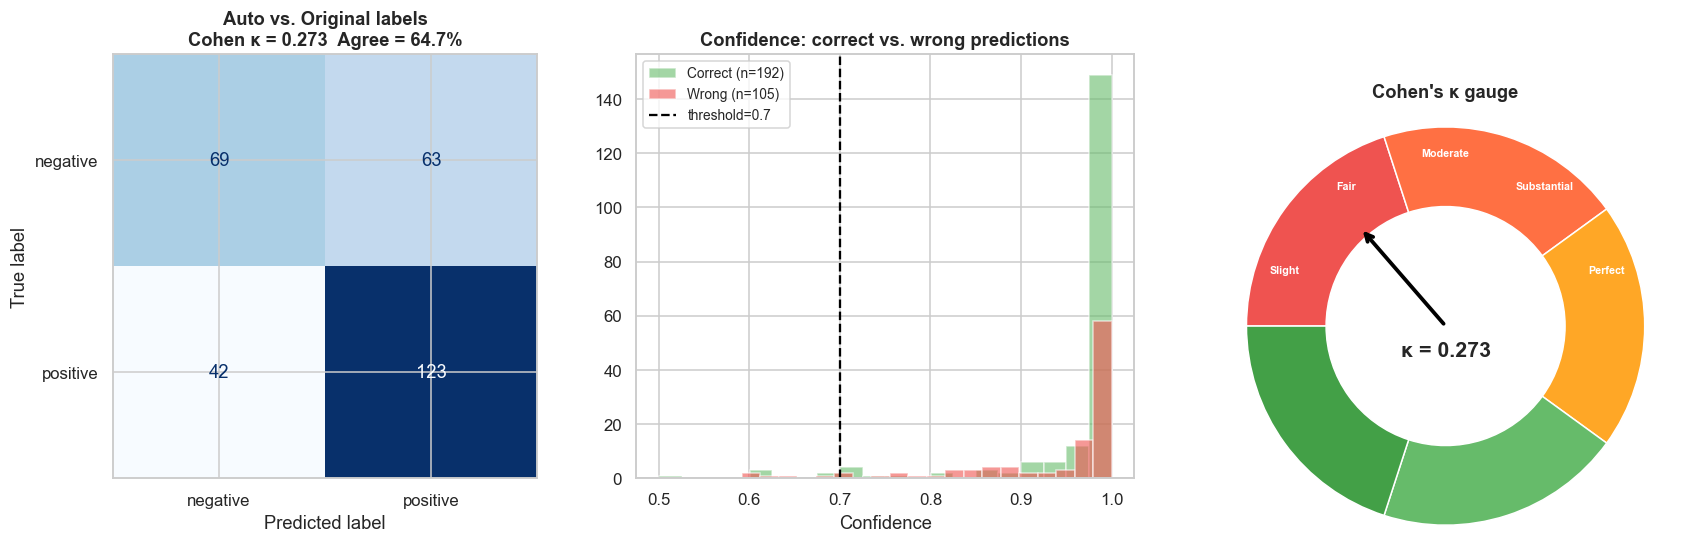

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion matrix (auto vs. original)
valid = df_labeled[['label', 'predicted_label']].dropna()
valid = valid[valid['predicted_label'] != 'unknown']
cm = confusion_matrix(valid['label'], valid['predicted_label'],
                      labels=['negative', 'positive'])
disp = ConfusionMatrixDisplay(cm, display_labels=['negative', 'positive'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(
    f'Auto vs. Original labels\nCohen κ = {metrics["kappa"]:.3f}  '
    f'Agree = {metrics["percent_agreement"]:.1f}%',
    fontweight='bold'
)

# Confidence by correctness
valid2 = df_labeled[['label', 'predicted_label', 'confidence']].dropna()
valid2 = valid2[valid2['predicted_label'] != 'unknown'].copy()
valid2['correct'] = valid2['label'] == valid2['predicted_label']
for correct, color, label in [(True, '#66BB6A', 'Correct'), (False, '#EF5350', 'Wrong')]:
    sub = valid2[valid2['correct'] == correct]['confidence']
    axes[1].hist(sub, bins=20, alpha=0.6, color=color, label=f'{label} (n={len(sub)})')
axes[1].axvline(agent.confidence_threshold, color='black', ls='--', lw=1.5,
                label=f'threshold={agent.confidence_threshold}')
axes[1].set_title('Confidence: correct vs. wrong predictions', fontweight='bold')
axes[1].set_xlabel('Confidence')
axes[1].legend(fontsize=9)

# Cohen's κ gauge
kappa = metrics.get('kappa') or 0
gauge_colors = ['#EF5350','#FF7043','#FFA726','#66BB6A','#43A047']
thresholds = [0.20, 0.40, 0.60, 0.80, 1.0]
labels_g = ['Slight','Fair','Moderate','Substantial','Perfect']
wedge_sizes = [20, 20, 20, 20, 20]
axes[2].pie(wedge_sizes, colors=gauge_colors, startangle=180,
            counterclock=False, wedgeprops={'width': 0.4})
# Mark κ position
angle = 180 - (kappa * 180)
import math
x = 0.65 * math.cos(math.radians(angle))
y = 0.65 * math.sin(math.radians(angle))
axes[2].annotate('', xy=(x, y), xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color='black', lw=2.5))
axes[2].text(0, -0.15, f'κ = {kappa:.3f}', ha='center', fontsize=14, fontweight='bold')
for i, (t, lbl) in enumerate(zip(thresholds, labels_g)):
    a = 180 - (t - 0.10) * 180
    axes[2].text(0.85 * math.cos(math.radians(a)),
                 0.85 * math.sin(math.radians(a)),
                 lbl, ha='center', fontsize=7, color='white', fontweight='bold')
axes[2].set_title("Cohen's κ gauge", fontweight='bold')
axes[2].set_ylim(-0.5, 1.1)

plt.tight_layout()
plt.savefig(ROOT / 'data/annotations/aplot_quality.png', bbox_inches='tight')
plt.show()

### Quality breakdown per source

In [8]:
from sklearn.metrics import cohen_kappa_score, accuracy_score

rows = []
for src in df_labeled['source'].unique():
    sub = df_labeled[df_labeled['source'] == src][['label', 'predicted_label', 'confidence']].dropna()
    sub = sub[sub['predicted_label'] != 'unknown']
    if len(sub) < 2:
        continue
    try:
        kappa = cohen_kappa_score(sub['label'], sub['predicted_label'])
    except Exception:
        kappa = None
    rows.append({
        'source': src,
        'n': len(sub),
        'kappa': round(kappa, 3) if kappa is not None else None,
        'accuracy': round(accuracy_score(sub['label'], sub['predicted_label']), 3),
        'mean_conf': round(sub['confidence'].mean(), 3),
    })

per_src_df = pd.DataFrame(rows)
display(per_src_df.style.background_gradient(subset=['kappa','accuracy','mean_conf'],
                                               cmap='RdYlGn', vmin=0, vmax=1).format(precision=3))

,source,n,kappa,accuracy,mean_conf
0,books_toscrape,100,0.023,0.520,0.953
1,imdb_huggingface,100,0.776,0.890,0.973
2,openlibrary_api,97,-0.198,0.526,0.938


---
## 4. LabelStudio Export 📤

In [9]:
export_result = agent.export_to_labelstudio(
    df_labeled,
    text_col='text',
    pred_col='predicted_label',
    conf_col='confidence',
    task_name='sentiment',
)

print('=== LabelStudio Export ===')
for k, v in export_result.items():
    if k != 'tasks':
        print(f'  {k}: {v}')

# Preview first task
print('\nFirst task (preview):')
import json
print(json.dumps(export_result['tasks'][0], indent=2, ensure_ascii=False))

2026-03-26 23:36:35,638 [INFO] agents.annotation_agent: LabelStudio export → /Users/trof1mov/Documents/itmo data for ml/data/annotations/labelstudio_import.json (297 tasks)


=== LabelStudio Export ===
  json_path: /Users/trof1mov/Documents/itmo data for ml/data/annotations/labelstudio_import.json
  config_path: /Users/trof1mov/Documents/itmo data for ml/data/annotations/labelstudio_config.xml
  n_tasks: 297
  n_with_predictions: 297

First task (preview):
{
  "id": 1,
  "data": {
    "text": "Chasing Heaven: What Dying Taught Me About Living"
  },
  "predictions": [
    {
      "model_version": "AnnotationAgent/distilbert-base-uncased-finetuned-sst-2-english",
      "score": 0.9918,
      "result": [
        {
          "id": "627fefe2",
          "type": "choices",
          "from_name": "sentiment",
          "to_name": "text",
          "value": {
            "choices": [
              "positive"
            ]
          }
        }
      ]
    }
  ]
}


In [10]:
# Show the label config XML for pasting into LabelStudio UI
config_path = export_result['config_path']
print('=== LabelStudio Config XML ===')
print('(Copy this into Project → Settings → Labeling Interface)\n')
print(open(config_path).read())

=== LabelStudio Config XML ===
(Copy this into Project → Settings → Labeling Interface)

<View>
  <Text name="text" value="$text" granularity="word"/>
  <Header value="Sentiment Classification"/>
  <Choices name="sentiment" toName="text" choice="single" showInLine="true">
    <Choice value="positive"/>
    <Choice value="negative"/>
  </Choices>
</View>


---
## 5. Bonus — Human-in-the-Loop (HITL) 🚦

The agent flags all predictions with `confidence < 0.70` for manual review.
These rows are saved to `data/annotations/hitl_review.csv` — ready to be
imported into LabelStudio as a priority annotation queue.

High-confidence predictions are auto-accepted and saved to `hitl_auto_accepted.csv`.

In [11]:
low_conf_df = agent.flag_low_confidence(df_labeled, threshold=0.70)
high_conf_df = df_labeled[df_labeled['confidence'] >= 0.70]

print(f'Total rows       : {len(df_labeled)}')
print(f'Auto-accepted    : {len(high_conf_df)}  (conf ≥ 0.70)')
print(f'Needs human review: {len(low_conf_df)}  (conf < 0.70)')
print(f'\nReview rate: {len(low_conf_df)/len(df_labeled)*100:.1f}%')

2026-03-26 23:36:35,648 [INFO] agents.annotation_agent: HITL: 11 low-conf (< 0.70) → /Users/trof1mov/Documents/itmo data for ml/data/annotations/hitl_review.csv  |  286 auto-accepted → /Users/trof1mov/Documents/itmo data for ml/data/annotations/hitl_auto_accepted.csv


Total rows       : 297
Auto-accepted    : 286  (conf ≥ 0.70)
Needs human review: 11  (conf < 0.70)

Review rate: 3.7%


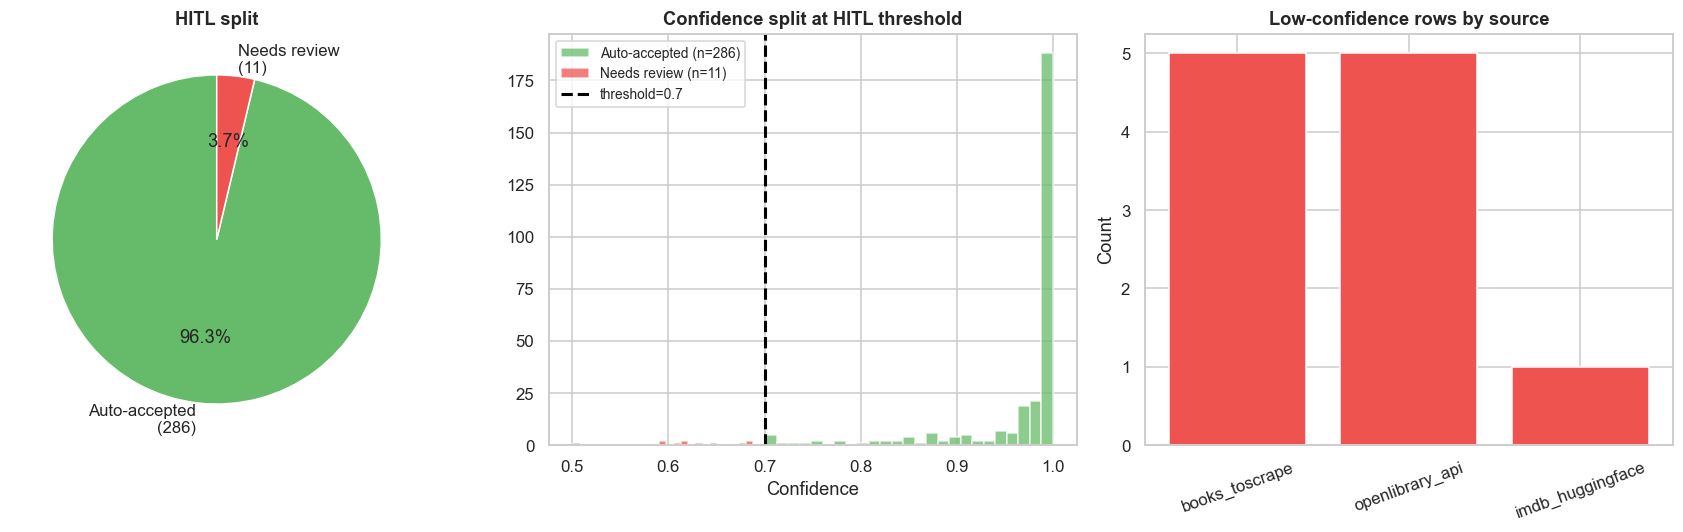


Sample low-confidence rows:


,text,label,predicted_label,confidence
0,Pollyanna,positive,positive,0.5005
1,The Scarlet Pimpernel,positive,negative,0.5916
2,There's a lot going on in The College Girl Mur...,positive,negative,0.5978
3,Germinal,positive,positive,0.6094
4,The White Queen (The Cousins' War #1),positive,positive,0.6179
5,"Giant Days, Vol. 2 (Giant Days #5-8)",negative,negative,0.6191
6,Мы,positive,negative,0.6312
7,The Last of the Mohicans,negative,positive,0.6469


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
thr = agent.confidence_threshold

# HITL split pie
n_low = len(low_conf_df)
n_high = len(high_conf_df)
axes[0].pie([n_high, n_low],
            labels=[f'Auto-accepted\n({n_high})', f'Needs review\n({n_low})'],
            colors=['#66BB6A', '#EF5350'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[0].set_title('HITL split', fontweight='bold')

# Confidence distribution colored by HITL decision
axes[1].hist(high_conf_df['confidence'], bins=25, color='#66BB6A',
             alpha=0.75, label=f'Auto-accepted (n={n_high})')
axes[1].hist(low_conf_df['confidence'], bins=25, color='#EF5350',
             alpha=0.75, label=f'Needs review (n={n_low})')
axes[1].axvline(thr, color='black', ls='--', lw=2, label=f'threshold={thr}')
axes[1].set_title('Confidence split at HITL threshold', fontweight='bold')
axes[1].set_xlabel('Confidence')
axes[1].legend(fontsize=9)

# Low-confidence examples by source
if len(low_conf_df) > 0 and 'source' in low_conf_df.columns:
    lc_src = low_conf_df['source'].value_counts()
    axes[2].bar(lc_src.index, lc_src.values, color='#EF5350', edgecolor='white')
    axes[2].set_title('Low-confidence rows by source', fontweight='bold')
    axes[2].set_ylabel('Count')
    axes[2].tick_params(axis='x', rotation=20)
else:
    axes[2].text(0.5, 0.5, 'No low-confidence rows', ha='center', va='center',
                 transform=axes[2].transAxes)

plt.tight_layout()
plt.savefig(ROOT / 'data/annotations/aplot_hitl.png', bbox_inches='tight')
plt.show()

print('\nSample low-confidence rows:')
display(low_conf_df[['text', 'label', 'predicted_label', 'confidence']]
        .sort_values('confidence').head(8).reset_index(drop=True))

### Export low-confidence subset to LabelStudio for priority review

In [13]:
if len(low_conf_df) > 0:
    hitl_export = agent.export_to_labelstudio(
        low_conf_df,
        output_filename='labelstudio_hitl_review.json',
    )
    print(f"HITL tasks exported: {hitl_export['n_tasks']} → {hitl_export['json_path']}")
else:
    print('No low-confidence examples to export.')

2026-03-26 23:36:35,845 [INFO] agents.annotation_agent: LabelStudio export → /Users/trof1mov/Documents/itmo data for ml/data/annotations/labelstudio_hitl_review.json (11 tasks)


HITL tasks exported: 11 → /Users/trof1mov/Documents/itmo data for ml/data/annotations/labelstudio_hitl_review.json


---
## Summary

In [14]:
print('=' * 55)
print('  ANNOTATION AGENT — FINAL SUMMARY')
print('=' * 55)
print(f'  Backend           : {agent._backend}')
print(f'  Rows labeled      : {len(df_labeled)}')
print(f'  Mean confidence   : {df_labeled["confidence"].mean():.3f}')
print(f"  Cohen's κ         : {metrics['kappa']:.3f}")
print(f"  Agreement         : {metrics['percent_agreement']:.1f}%")
print(f'  Low-conf (HITL)   : {len(low_conf_df)} ({len(low_conf_df)/len(df_labeled)*100:.1f}%)')
print('\n  Output files:')
import os
ann_dir = ROOT / 'data' / 'annotations'
for f in sorted(ann_dir.iterdir()):
    print(f'    {f.name}  ({f.stat().st_size // 1024} KB)')
print('=' * 55)

  ANNOTATION AGENT — FINAL SUMMARY
  Backend           : neural
  Rows labeled      : 297
  Mean confidence   : 0.955
  Cohen's κ         : 0.273
  Agreement         : 64.7%
  Low-conf (HITL)   : 11 (3.7%)

  Output files:


    annotation_spec.md  (3 KB)
    aplot_hitl.png  (62 KB)
    aplot_label_confidence.png  (46 KB)
    aplot_quality.png  (74 KB)
    hitl_auto_accepted.csv  (162 KB)
    hitl_review.csv  (3 KB)
    labelstudio_config.xml  (0 KB)
    labelstudio_hitl_review.json  (8 KB)
    labelstudio_import.json  (294 KB)
